# LOAD & SHUFFLE DATA

In [ ]:
import pandas as pd
from sklearn.utils import shuffle

df = pd.read_excel('Gestational Diabetic Dat Set.xlsx')

df = shuffle(df, random_state=42)

X = df.drop(['Case Number','Class Label(GDM /Non GDM)'], axis=1)
y = df['Class Label(GDM /Non GDM)']

# PREPROCESSING


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# SMOTE


Class Label(GDM /Non GDM)
0    2153
1    1372
Name: count, dtype: int64


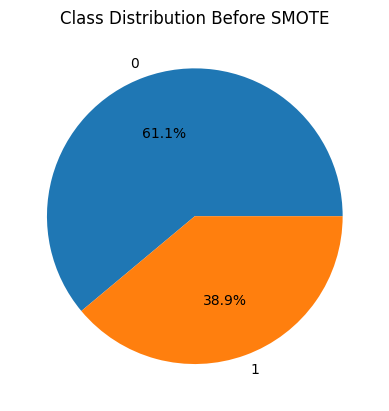

In [ ]:
import matplotlib.pyplot as plt
print(y.value_counts())
y.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Class Distribution Before SMOTE")
plt.ylabel("")
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

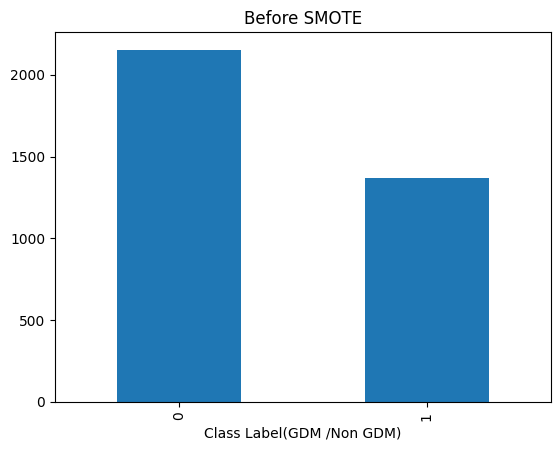

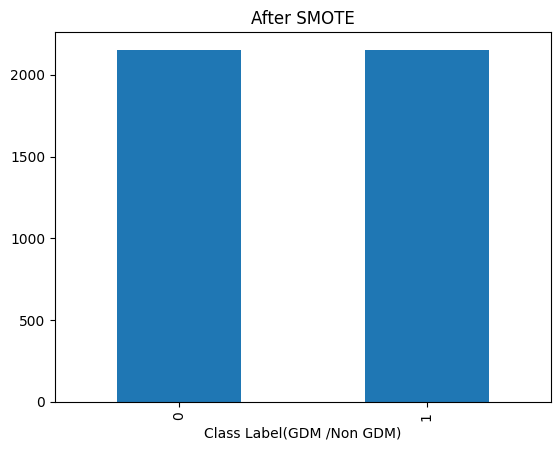

In [ ]:
import seaborn as sns

before = df['Class Label(GDM /Non GDM)'].value_counts()
after = pd.Series(y).value_counts()

plt.figure()
before.plot(kind='bar')
plt.title("Before SMOTE")
plt.show()

plt.figure()
after.plot(kind='bar')
plt.title("After SMOTE")
plt.show()

# FEATURE SELECTION


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
X = selector.fit_transform(X, y)

# MODELS


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
models = {
    "RF": RandomForestClassifier(),
    "ET": ExtraTreesClassifier(),
    "XGB": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LGBM": LGBMClassifier(),
    "CAT": CatBoostClassifier(verbose=0),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "DT": DecisionTreeClassifier(),
    "GB": GradientBoostingClassifier(),
    "ADA": AdaBoostClassifier(),
    "LR": LogisticRegression(max_iter=1000),
    "MLP": MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=500)
}

# DBN


In [ ]:
from sklearn.neural_network import BernoulliRBM
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

rbm1 = BernoulliRBM(n_components=128, learning_rate=0.01, n_iter=20)
rbm2 = BernoulliRBM(n_components=64, learning_rate=0.01, n_iter=20)
rbm3 = BernoulliRBM(n_components=32, learning_rate=0.01, n_iter=20)

logistic = LogisticRegression(max_iter=1000)

dbn = Pipeline([
    ("rbm1", rbm1),
    ("rbm2", rbm2),
    ("rbm3", rbm3),
    ("logistic", logistic)
])

# STACKING


In [ ]:
from sklearn.ensemble import StackingClassifier

base_models = [
    ('rf', RandomForestClassifier()),
    ('et', ExtraTreesClassifier()),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
]

meta_model = LogisticRegression()

stack_model = StackingClassifier(estimators=base_models, final_estimator=meta_model)

# CROSS VALIDATION


In [ ]:
from sklearn.model_selection import cross_validate

results = {}

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy','precision','recall','f1','roc_auc'])
    results[name] = scores

scores_dbn = cross_validate(dbn, X, y, cv=5, scoring=['accuracy','precision','recall','f1','roc_auc'])
results['DBN'] = scores_dbn

scores_stack = cross_validate(stack_model, X, y, cv=5, scoring=['accuracy','precision','recall','f1','roc_auc'])
results['STACK'] = scores_stack

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:39:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:39:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:39:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:39:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

[LightGBM] [Info] Number of positive: 1722, number of negative: 1722
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000787 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1407
[LightGBM] [Info] Number of data points in the train set: 3444, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1723, number of negative: 1722
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1404
[LightGBM] [Info] Number of data points in the train set: 3445, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500145 -> initscor

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1723, number of negative: 1722
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000542 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1404
[LightGBM] [Info] Number of data points in the train set: 3445, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500145 -> initscore=0.000581
[LightGBM] [Info] Start training from score 0.000581
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1722, number of negative: 1723
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1386
[LightGBM] [Info] Number of data points in the train set: 3445, number of used features: 10
[LightGBM] [Inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1722, number of negative: 1723
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1191
[LightGBM] [Info] Number of data points in the train set: 3445, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499855 -> initscore=-0.000581
[LightGBM] [Info] Start training from score -0.000581
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:41:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:41:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:41:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters

# RESULTS

In [ ]:
import numpy as np

final_results = []

for name, score in results.items():
    final_results.append([
        name,
        np.mean(score['test_accuracy']),
        np.mean(score['test_precision']),
        np.mean(score['test_recall']),
        np.mean(score['test_f1']),
        np.mean(score['test_roc_auc'])
    ])

df_results = pd.DataFrame(final_results, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])
df_results = df_results.sort_values(by=["Accuracy","F1"], ascending=False)
print(df_results)

    Model  Accuracy  Precision    Recall        F1       AUC
11    MLP  0.978636   0.974393  0.983275  0.978728  0.994139
5     SVM  0.978635   0.968303  0.989781  0.978891  0.994642
4     CAT  0.978403   0.973165  0.984205  0.978547  0.998379
13  STACK  0.977474   0.974321  0.980951  0.977520  0.999072
1      ET  0.977474   0.971279  0.984200  0.977614  0.999120
6     KNN  0.977242   0.969022  0.986067  0.977449  0.991317
3    LGBM  0.977010   0.971683  0.982810  0.977131  0.998681
2     XGB  0.976081   0.970368  0.982348  0.976229  0.998363
0      RF  0.974689   0.963840  0.986529  0.974993  0.998572
8      GB  0.973760   0.972911  0.974918  0.973773  0.997872
7      DT  0.971669   0.970902  0.972596  0.971677  0.971665
9     ADA  0.971204   0.972586  0.969811  0.971157  0.997282
10     LR  0.962844   0.967765  0.957741  0.962650  0.985768
12    DBN  0.921272   0.960024  0.879245  0.917792  0.943735


# VISUALIZATION

Accuracy

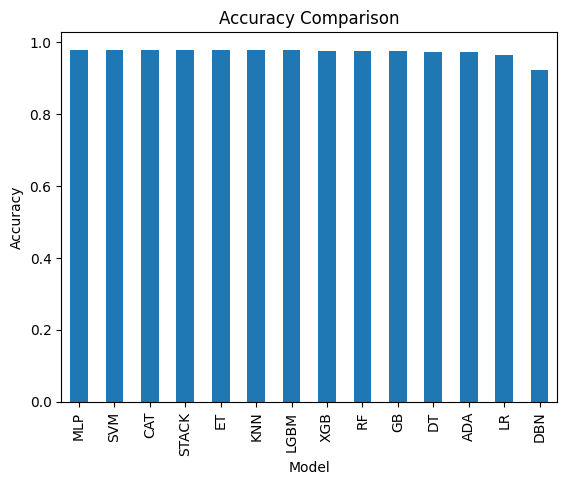

In [ ]:
import matplotlib.pyplot as plt

df_results.set_index("Model")["Accuracy"].plot(kind='bar')
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()

F1 Score

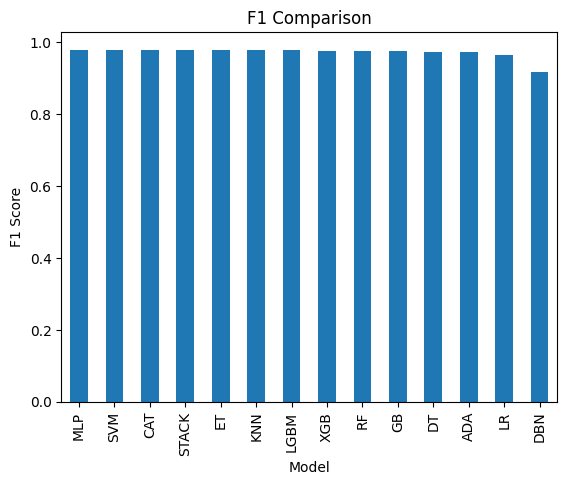

In [ ]:
df_results.set_index("Model")["F1"].plot(kind='bar')
plt.ylabel("F1 Score")
plt.title("F1 Comparison")
plt.show()

Recall

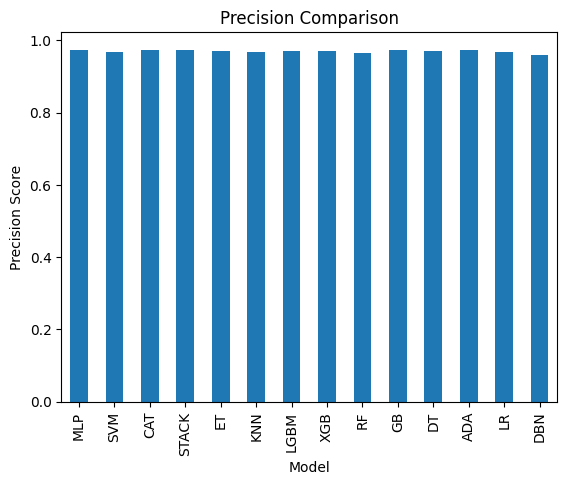

In [ ]:
df_results.set_index("Model")["Precision"].plot(kind='bar')
plt.ylabel("Precision Score")
plt.title("Precision Comparison")
plt.show()

Precision

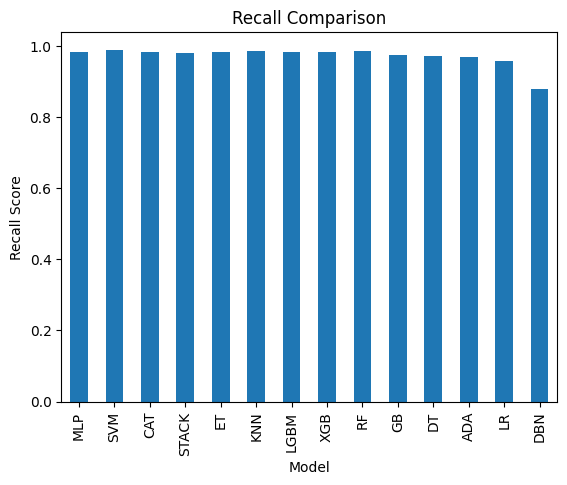

In [ ]:
df_results.set_index("Model")["Recall"].plot(kind="bar")
plt.ylabel("Recall Score")
plt.title("Recall Comparison")
plt.show()

ROC Curve

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:42:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:42:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


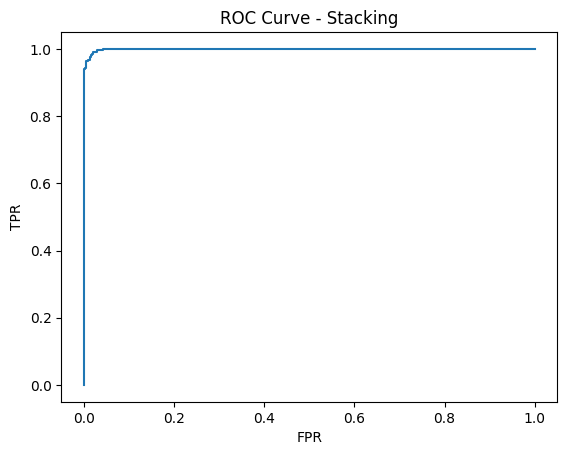

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

stack_model.fit(X_train, y_train)
y_prob = stack_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Stacking")
plt.show()

In [ ]:
import numpy as np

print("Enter Patient Details:\n")

age = float(input("Age: "))
preg = float(input("No of Pregnancies: "))
gest = float(input("Gestation: "))
bmi = float(input("BMI: "))
hdl = float(input("HDL: "))
family = float(input("Family History (0/1): "))
unexplained = float(input("Unexplained Prenatal Loss (0/1): "))
large_child = float(input("Large Child (0/1): "))
pcos = float(input("PCOS (0/1): "))
sys_bp = float(input("Systolic BP: "))
dia_bp = float(input("Diastolic BP: "))
ogtt = float(input("OGTT: "))
hemo = float(input("Hemoglobin: "))
sedentary = float(input("Sedentary Lifestyle (0/1): "))
prediabetes = float(input("Prediabetes (0/1): "))


user_data = np.array([[age, preg, gest, bmi, hdl, family,
                       unexplained, large_child, pcos,
                       sys_bp, dia_bp, ogtt,
                       hemo, sedentary, prediabetes]])

print("\nOriginal User Input:")
print(user_data)

user_data = imputer.transform(user_data)
user_data = scaler.transform(user_data)
user_data = selector.transform(user_data)


mlp_model = MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=500)

mlp_model.fit(X, y)


prediction = mlp_model.predict(user_data)

if prediction[0] == 1:
    print("\nResult: GDM Detected")
else:
    print("\nResult: No GDM")

Enter Patient Details:

Age: 25
No of Pregnancies: 1
Gestation: 1
BMI: 23
HDL: 55
Family History (0/1): 0
Unexplained Prenatal Loss (0/1): 0
Large Child (0/1): 0
PCOS (0/1): 0
Systolic BP: 110
Diastolic BP: 75
OGTT: 113
Hemoglobin: 13
Sedentary Lifestyle (0/1): 0
Prediabetes (0/1): 0

Original User Input:
[[ 25.   1.   1.  23.  55.   0.   0.   0.   0. 110.  75. 113.  13.   0.
    0.]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(



Result: No GDM
